In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split
from torch_geometric.nn import SAGEConv, to_hetero
from torch_geometric.loader import DataLoader
from torch.utils.tensorboard import SummaryWriter
from pathlib import Path
from tqdm.notebook import tqdm
import time

from halide_gnn_cost_model.data import PipelineDataset
from halide_gnn_cost_model.model import PipeGCN, PipeGAT, PipelineModel

In [2]:
PIPELINES_DIR = Path("/lscratch/fzhou48/pipelines-16k-data")
GCN_MODELS_DIR = Path("/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/resources/models/gcn")
GAT_MODELS_DIR = Path("/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/resources/models/gat")
# Create models directory if it doesn't exist
GCN_MODELS_DIR.mkdir(parents=True, exist_ok=True)
GAT_MODELS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
USE_GPU = True

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
elif USE_GPU and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
# Load dataset
dataset = PipelineDataset(PIPELINES_DIR)
data = dataset[0]  # Get the first pipeline graph
data.metadata()

1lines [00:00, 6657.63lines/s]
1lines [00:00, 32263.88lines/s]


(['function', 'ast_node', 'loop_level'],
 [('function', 'called_by', 'function'),
  ('function', 'call', 'function'),
  ('ast_node', 'child_of', 'ast_node'),
  ('ast_node', 'parent_of', 'ast_node'),
  ('ast_node', 'is_expr_of', 'function'),
  ('function', 'contains_expr', 'ast_node'),
  ('loop_level', 'child_of', 'loop_level'),
  ('loop_level', 'parent_of', 'loop_level'),
  ('function', 'schedule_at', 'loop_level'),
  ('loop_level', 'schedule', 'function')])

In [5]:
# Train/test split
num_train = int(0.95 * len(dataset))
train_dataset, test_dataset = random_split(dataset, [num_train, len(dataset) - num_train])
len(train_dataset), len(test_dataset)

(15605, 822)

# GCN

In [6]:
DIM_EMBEDDING = 64
gcn = PipeGCN(hidden_channels=DIM_EMBEDDING, out_channels=DIM_EMBEDDING, num_layers=4)
gcn = to_hetero(gcn, data.metadata(), aggr="sum")

/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()
/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout_1' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()
/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout_2' with keyword argument 'traini

In [7]:
model = PipelineModel(gcn, DIM_EMBEDDING, 5, len(dataset.ast_vocab), len(dataset.sched_vocab))
model = model.to(device)
model

PipelineModel(
  (function_gnn): GraphModule(
    (convs): ModuleList(
      (0-3): 4 x ModuleDict(
        (function__called_by__function): SAGEConv(-1, 64, aggr=add)
        (function__call__function): SAGEConv(-1, 64, aggr=add)
        (ast_node__child_of__ast_node): SAGEConv(-1, 64, aggr=add)
        (ast_node__parent_of__ast_node): SAGEConv(-1, 64, aggr=add)
        (ast_node__is_expr_of__function): SAGEConv(-1, 64, aggr=add)
        (function__contains_expr__ast_node): SAGEConv(-1, 64, aggr=add)
        (loop_level__child_of__loop_level): SAGEConv(-1, 64, aggr=add)
        (loop_level__parent_of__loop_level): SAGEConv(-1, 64, aggr=add)
        (function__schedule_at__loop_level): SAGEConv(-1, 64, aggr=add)
        (loop_level__schedule__function): SAGEConv(-1, 64, aggr=add)
      )
    )
  )
  (ast_embedding): Embedding(14, 32)
  (sched_embedding): Embedding(8, 32)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=Tr

In [8]:
data_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=12)
data_loader

/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 8, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [9]:
# Save model every n epochs
SAVE_EVERY = 20
NUM_EPOCHS = 400

# Train loop (example)
summary_writer = SummaryWriter(log_dir="resources/runs/" + time.strftime("gcn-%Y%m%d-%H%M%S"))
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
criterion = torch.nn.MSELoss()

for epoch in tqdm(range(NUM_EPOCHS)):
    model.train()
    total_loss = 0
    for batch_idx, batch in enumerate(data_loader):
        optimizer.zero_grad()
        batch = batch.to(device)
        pred = model(batch, batch["loop_level"].ptr)
        # Assuming batch.y contains the true runtimes
        loss = criterion(pred.reshape(-1), torch.log(batch.y))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        summary_writer.add_scalar("Loss/train", loss.item(), epoch * len(data_loader) + batch_idx)
    # Print average loss for the epoch
    avg_loss = total_loss / len(data_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    # Save model
    if (epoch + 1) % SAVE_EVERY == 0:
        torch.save(model.state_dict(), GCN_MODELS_DIR / f"pipeline_model_epoch_{epoch+1}.pt")

  0%|          | 0/400 [00:00<?, ?it/s]

Epoch 1, Loss: 8.5475
Epoch 2, Loss: 1.9936
Epoch 3, Loss: 1.7368
Epoch 4, Loss: 1.5783
Epoch 5, Loss: 1.5059
Epoch 6, Loss: 1.4181
Epoch 7, Loss: 1.3546
Epoch 8, Loss: 1.3169
Epoch 9, Loss: 1.2769
Epoch 10, Loss: 1.2512
Epoch 11, Loss: 1.2117
Epoch 12, Loss: 1.1951
Epoch 13, Loss: 1.1648
Epoch 14, Loss: 1.1483
Epoch 15, Loss: 1.1379
Epoch 16, Loss: 1.1157
Epoch 17, Loss: 1.1183
Epoch 18, Loss: 1.0919
Epoch 19, Loss: 1.0911
Epoch 20, Loss: 1.0692
Epoch 21, Loss: 1.0623
Epoch 22, Loss: 1.0563
Epoch 23, Loss: 1.0497
Epoch 24, Loss: 1.0424
Epoch 25, Loss: 1.0425
Epoch 26, Loss: 1.0185
Epoch 27, Loss: 1.0172
Epoch 28, Loss: 0.9951
Epoch 29, Loss: 0.9932
Epoch 30, Loss: 0.9746
Epoch 31, Loss: 0.9602
Epoch 32, Loss: 0.9574
Epoch 33, Loss: 0.9232
Epoch 34, Loss: 0.9114
Epoch 35, Loss: 0.8969
Epoch 36, Loss: 0.8918
Epoch 37, Loss: 0.8694
Epoch 38, Loss: 0.8550
Epoch 39, Loss: 0.8351
Epoch 40, Loss: 0.8328
Epoch 41, Loss: 0.8087
Epoch 42, Loss: 0.7993
Epoch 43, Loss: 0.7964
Epoch 44, Loss: 0.79

## Eval

In [10]:
def average_runtime_error(model, data_loader):
    model.eval()
    total_error = 0
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            pred = model(batch, batch["loop_level"].ptr)
            error_rates = torch.abs(pred.reshape(-1) - batch.y) / batch.y
            total_error += torch.mean(error_rates).item()
    return total_error / len(data_loader)

In [11]:
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
print(f"Average Runtime Error on Test Set: {average_runtime_error(model, test_loader) * 100:.2f}%")

Average Runtime Error on Test Set: 214.68%


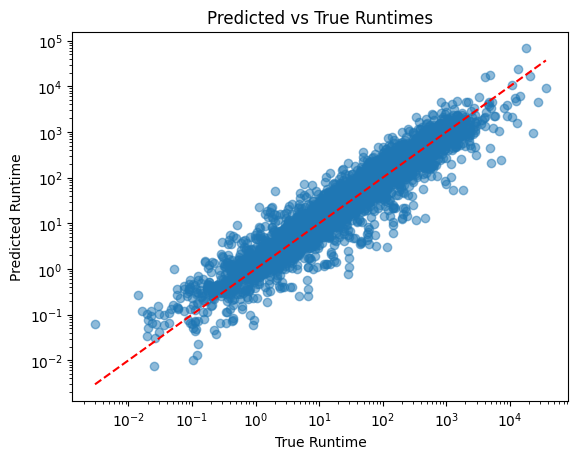

In [12]:
# Plot predicted vs actual runtimes
import matplotlib.pyplot as plt
all_preds = []
all_trues = []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        pred = torch.exp(model(batch, batch["loop_level"].ptr))
        all_preds.append(pred.reshape(-1).cpu())
        all_trues.append(batch.y.cpu())
all_preds = torch.cat(all_preds)
all_trues = torch.cat(all_trues)
plt.scatter(all_trues, all_preds, alpha=0.5)
plt.plot([all_trues.min(), all_trues.max()], [all_trues.min(), all_trues.max()], 'r--')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("True Runtime")
plt.ylabel("Predicted Runtime")
plt.title("Predicted vs True Runtimes")
plt.show()

In [13]:
idx = 0  # Index of the sample to inspect
model.eval()
with torch.no_grad():
    sample_data = test_dataset[idx]
    sample_data = sample_data.to(device)
    pred_runtime = torch.exp(model(sample_data))
    print(f"Predicted runtime: {pred_runtime}, True runtime: {sample_data.y}")

Predicted runtime: tensor([[   4.6280,   18.7828,   90.0276,  387.1661, 1856.2042]],
       device='cuda:0'), True runtime: tensor([  27.0072,  110.3606,  448.3829, 1963.6451, 8222.4883],
       device='cuda:0')


# GAT

In [14]:
DIM_EMBEDDING = 64
gcn = PipeGAT(hidden_channels=DIM_EMBEDDING, out_channels=DIM_EMBEDDING, num_layers=4, heads=8)
gcn = to_hetero(gcn, data.metadata(), aggr="sum")

/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()
/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout_1' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()
/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout_2' with keyword argument 'traini

In [15]:
model = PipelineModel(gcn, DIM_EMBEDDING, 5, len(dataset.ast_vocab), len(dataset.sched_vocab))
model = model.to(device)
model

PipelineModel(
  (function_gnn): GraphModule(
    (convs): ModuleList(
      (0-3): 4 x ModuleDict(
        (function__called_by__function): GATConv(-1, 64, heads=8)
        (function__call__function): GATConv(-1, 64, heads=8)
        (ast_node__child_of__ast_node): GATConv(-1, 64, heads=8)
        (ast_node__parent_of__ast_node): GATConv(-1, 64, heads=8)
        (ast_node__is_expr_of__function): GATConv(-1, 64, heads=8)
        (function__contains_expr__ast_node): GATConv(-1, 64, heads=8)
        (loop_level__child_of__loop_level): GATConv(-1, 64, heads=8)
        (loop_level__parent_of__loop_level): GATConv(-1, 64, heads=8)
        (function__schedule_at__loop_level): GATConv(-1, 64, heads=8)
        (loop_level__schedule__function): GATConv(-1, 64, heads=8)
      )
    )
  )
  (ast_embedding): Embedding(14, 32)
  (sched_embedding): Embedding(8, 32)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (fc3): Linear(

In [16]:
data_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=12)
data_loader

/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 8, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [17]:
# Save model every n epochs
SAVE_EVERY = 20
NUM_EPOCHS = 400

# Train loop (example)
summary_writer = SummaryWriter(log_dir="resources/runs/" + time.strftime("gat-%Y%m%d-%H%M%S"))
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
criterion = torch.nn.MSELoss()

for epoch in tqdm(range(NUM_EPOCHS)):
    model.train()
    total_loss = 0
    for batch_idx, batch in enumerate(data_loader):
        optimizer.zero_grad()
        batch = batch.to(device)
        pred = model(batch, batch["loop_level"].ptr)
        # Assuming batch.y contains the true runtimes
        loss = criterion(pred.reshape(-1), torch.log(batch.y))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        summary_writer.add_scalar("Loss/train", loss.item(), epoch * len(data_loader) + batch_idx)
    # Print average loss for the epoch
    avg_loss = total_loss / len(data_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    # Save model
    if (epoch + 1) % SAVE_EVERY == 0:
        torch.save(model.state_dict(), GAT_MODELS_DIR / f"pipeline_model_epoch_{epoch+1}.pt")

  0%|          | 0/400 [00:00<?, ?it/s]

Epoch 1, Loss: 3.3062
Epoch 2, Loss: 1.8455
Epoch 3, Loss: 1.4879
Epoch 4, Loss: 1.3473
Epoch 5, Loss: 1.2625
Epoch 6, Loss: 1.2332
Epoch 7, Loss: 1.1666
Epoch 8, Loss: 1.1262
Epoch 9, Loss: 1.1011
Epoch 10, Loss: 1.0753
Epoch 11, Loss: 1.0554
Epoch 12, Loss: 1.0202
Epoch 13, Loss: 0.9931
Epoch 14, Loss: 0.9656
Epoch 15, Loss: 0.9235
Epoch 16, Loss: 0.9115
Epoch 17, Loss: 0.8900
Epoch 18, Loss: 0.8659
Epoch 19, Loss: 0.8518
Epoch 20, Loss: 0.8244
Epoch 21, Loss: 0.8084
Epoch 22, Loss: 0.7896
Epoch 23, Loss: 0.7778
Epoch 24, Loss: 0.7849
Epoch 25, Loss: 0.7584
Epoch 26, Loss: 0.7655
Epoch 27, Loss: 0.7488
Epoch 28, Loss: 0.7312
Epoch 29, Loss: 0.7326
Epoch 30, Loss: 0.7198
Epoch 31, Loss: 0.7124
Epoch 32, Loss: 0.7193
Epoch 33, Loss: 0.7058
Epoch 34, Loss: 0.7208
Epoch 35, Loss: 0.7146
Epoch 36, Loss: 0.7105
Epoch 37, Loss: 0.6944
Epoch 38, Loss: 0.7193
Epoch 39, Loss: 0.6991
Epoch 40, Loss: 0.6817
Epoch 41, Loss: 0.6892
Epoch 42, Loss: 0.6772
Epoch 43, Loss: 0.6784
Epoch 44, Loss: 0.67

## Eval

In [20]:
def average_runtime_error(model, data_loader):
    model.eval()
    total_error = 0
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            pred = model(batch, batch["loop_level"].ptr)
            error_rates = torch.abs(pred.reshape(-1) - batch.y) / batch.y
            total_error += torch.mean(error_rates).item()
    return total_error / len(data_loader)

In [21]:
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
print(f"Average Runtime Error on Test Set: {average_runtime_error(model, test_loader) * 100:.2f}%")

Average Runtime Error on Test Set: 206.90%


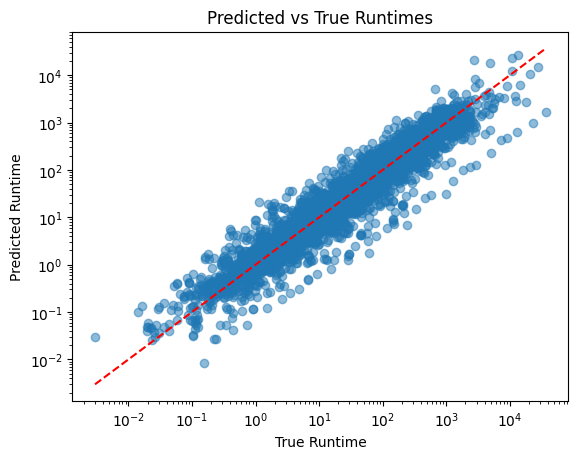

In [22]:
# Plot predicted vs actual runtimes
import matplotlib.pyplot as plt
all_preds = []
all_trues = []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        pred = torch.exp(model(batch, batch["loop_level"].ptr))
        all_preds.append(pred.reshape(-1).cpu())
        all_trues.append(batch.y.cpu())
all_preds = torch.cat(all_preds)
all_trues = torch.cat(all_trues)
plt.scatter(all_trues, all_preds, alpha=0.5)
plt.plot([all_trues.min(), all_trues.max()], [all_trues.min(), all_trues.max()], 'r--')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("True Runtime")
plt.ylabel("Predicted Runtime")
plt.title("Predicted vs True Runtimes")
plt.show()

In [23]:
idx = 0  # Index of the sample to inspect
model.eval()
with torch.no_grad():
    sample_data = test_dataset[idx]
    sample_data = sample_data.to(device)
    pred_runtime = torch.exp(model(sample_data))
    print(f"Predicted runtime: {pred_runtime}, True runtime: {sample_data.y}")

Predicted runtime: tensor([[   6.3968,   28.0750,  136.3304,  595.3399, 2722.6523]],
       device='cuda:0'), True runtime: tensor([  27.0072,  110.3606,  448.3829, 1963.6451, 8222.4883],
       device='cuda:0')


# Graph Transformer